# Why Activation Functions Matter — Building Intuition

We'll try to learn a simple curved function: **y = sin(x)**

This is a nonlinear function. Let's see what happens when we try to learn it
with and without activation functions.

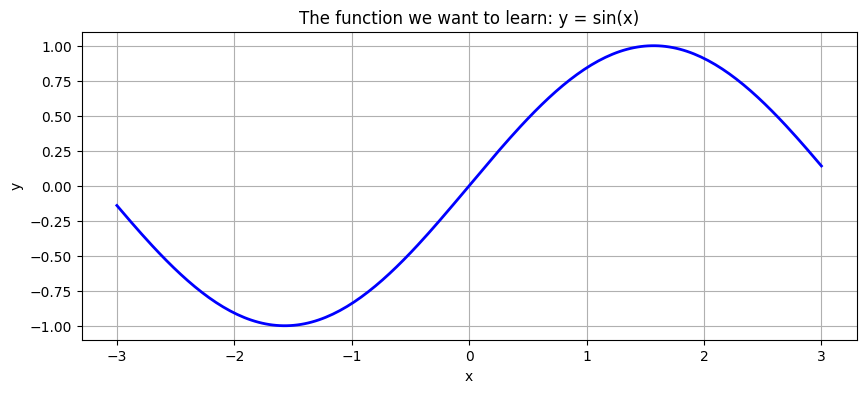

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Generate training data: y = sin(x)
torch.manual_seed(42)
X = torch.linspace(-3, 3, 200).unsqueeze(1)  # 200 points, shape (200, 1)
Y = torch.sin(X)                               # target: sin(x)

plt.figure(figsize=(10, 4))
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2)
plt.title('The function we want to learn: y = sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

## Network WITHOUT activation (just linear layers)

Architecture: 1 input → 50 hidden → 50 hidden → 1 output

50 neurons per layer! Surely that's enough? Let's see.

Final loss (no activation): 0.167995


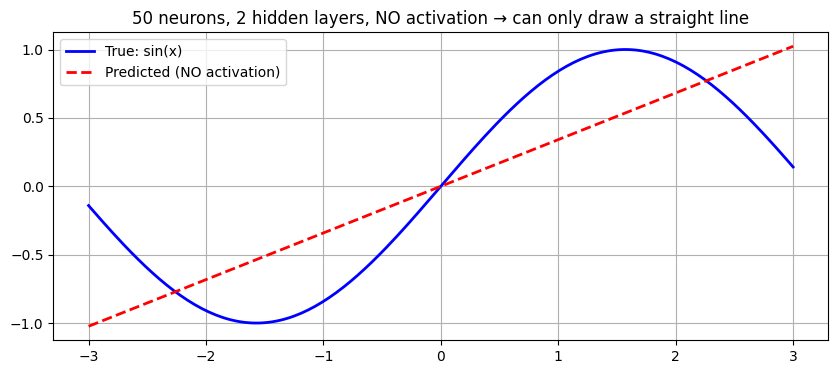

In [2]:
# Network with NO activation function
linear_net = nn.Sequential(
    nn.Linear(1, 50),
    # no activation!
    nn.Linear(50, 50),
    # no activation!
    nn.Linear(50, 1),
)

optimizer = torch.optim.Adam(linear_net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Train for 2000 steps
for step in range(2000):
    pred = linear_net(X)
    loss = loss_fn(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'Final loss (no activation): {loss.item():.6f}')

# Plot
with torch.no_grad():
    pred_linear = linear_net(X)

plt.figure(figsize=(10, 4))
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='True: sin(x)')
plt.plot(X.numpy(), pred_linear.numpy(), 'r--', linewidth=2, label='Predicted (NO activation)')
plt.title('50 neurons, 2 hidden layers, NO activation → can only draw a straight line')
plt.legend()
plt.grid(True)
plt.show()

## Network WITH activation (ReLU)

Same architecture: 1 input → 50 hidden → 50 hidden → 1 output

Only difference: we add ReLU between layers.

Final loss (with ReLU): 0.000033


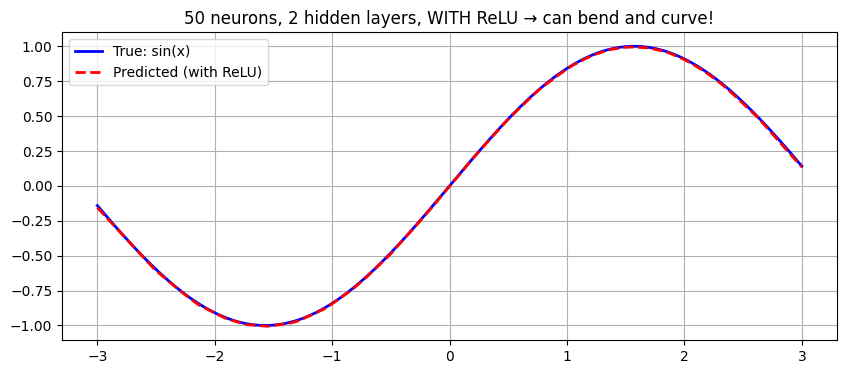

In [3]:
# Network WITH ReLU activation
relu_net = nn.Sequential(
    nn.Linear(1, 50),
    nn.ReLU(),           # <-- this is the only difference
    nn.Linear(50, 50),
    nn.ReLU(),           # <-- and this
    nn.Linear(50, 1),
)

optimizer = torch.optim.Adam(relu_net.parameters(), lr=0.01)

# Train for 2000 steps (same as before)
for step in range(2000):
    pred = relu_net(X)
    loss = loss_fn(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'Final loss (with ReLU): {loss.item():.6f}')

# Plot
with torch.no_grad():
    pred_relu = relu_net(X)

plt.figure(figsize=(10, 4))
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='True: sin(x)')
plt.plot(X.numpy(), pred_relu.numpy(), 'r--', linewidth=2, label='Predicted (with ReLU)')
plt.title('50 neurons, 2 hidden layers, WITH ReLU → can bend and curve!')
plt.legend()
plt.grid(True)
plt.show()

## Side by side comparison

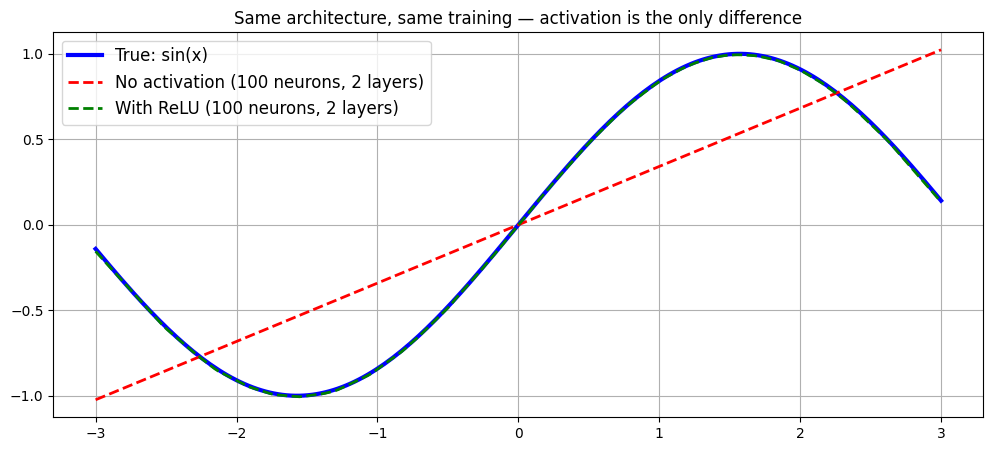

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(X.numpy(), Y.numpy(), 'b-', linewidth=3, label='True: sin(x)')
plt.plot(X.numpy(), pred_linear.numpy(), 'r--', linewidth=2, label='No activation (100 neurons, 2 layers)')
plt.plot(X.numpy(), pred_relu.numpy(), 'g--', linewidth=2, label='With ReLU (100 neurons, 2 layers)')
plt.title('Same architecture, same training — activation is the only difference')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## Now the KEY insight: what is each neuron actually doing?

Let's look inside the ReLU network and see what individual neurons output.

Each neuron computes `ReLU(w*x + b)` — that's a line that's zero on one side
and rises on the other. The network's final output is a weighted sum of all these.

It's literally stitching together little line segments to approximate the curve.

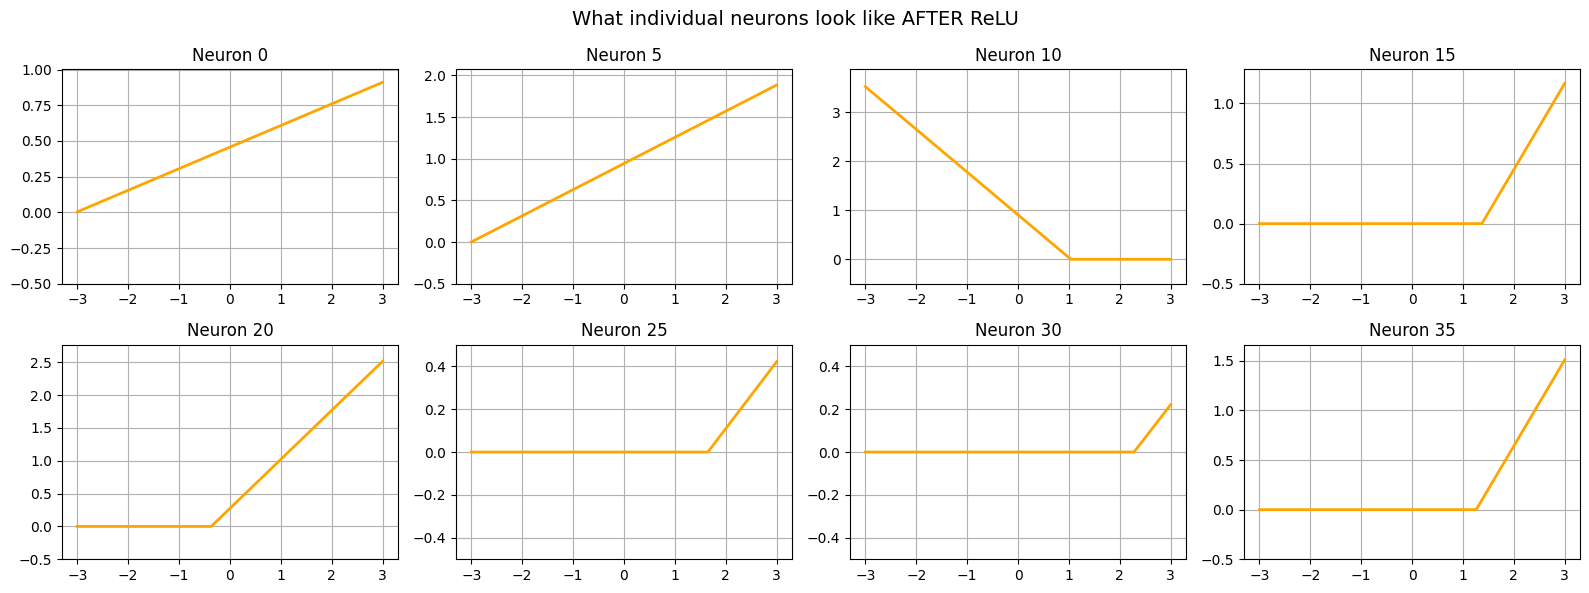

Each neuron is just a simple ramp — zero on one side, linear on the other.
But when you ADD many of these together with different weights...
you can approximate ANY curve. That's the magic.


In [5]:
# Let's look at what the first layer neurons output
with torch.no_grad():
    # Get first layer output (before and after ReLU)
    first_layer = relu_net[0]  # Linear layer
    pre_activation = first_layer(X)   # shape: (200, 50) — 50 neurons
    post_activation = torch.relu(pre_activation)  # after ReLU

# Plot 8 random neurons from the first layer
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('What individual neurons look like AFTER ReLU', fontsize=14)

neuron_indices = [0, 5, 10, 15, 20, 25, 30, 35]
for i, idx in enumerate(neuron_indices):
    ax = axes[i // 4][i % 4]
    ax.plot(X.numpy(), post_activation[:, idx].numpy(), 'orange', linewidth=2)
    ax.set_title(f'Neuron {idx}')
    ax.grid(True)
    ax.set_ylim(-0.5, max(post_activation[:, idx].max().item() * 1.1, 0.5))

plt.tight_layout()
plt.show()

print("Each neuron is just a simple ramp — zero on one side, linear on the other.")
print("But when you ADD many of these together with different weights...")
print("you can approximate ANY curve. That's the magic.")

## Building up the curve piece by piece

Let's see how adding more neurons gradually builds up the approximation.

We'll train networks with 1, 2, 3, 5, 10, and 50 neurons and watch
the function go from terrible to great.

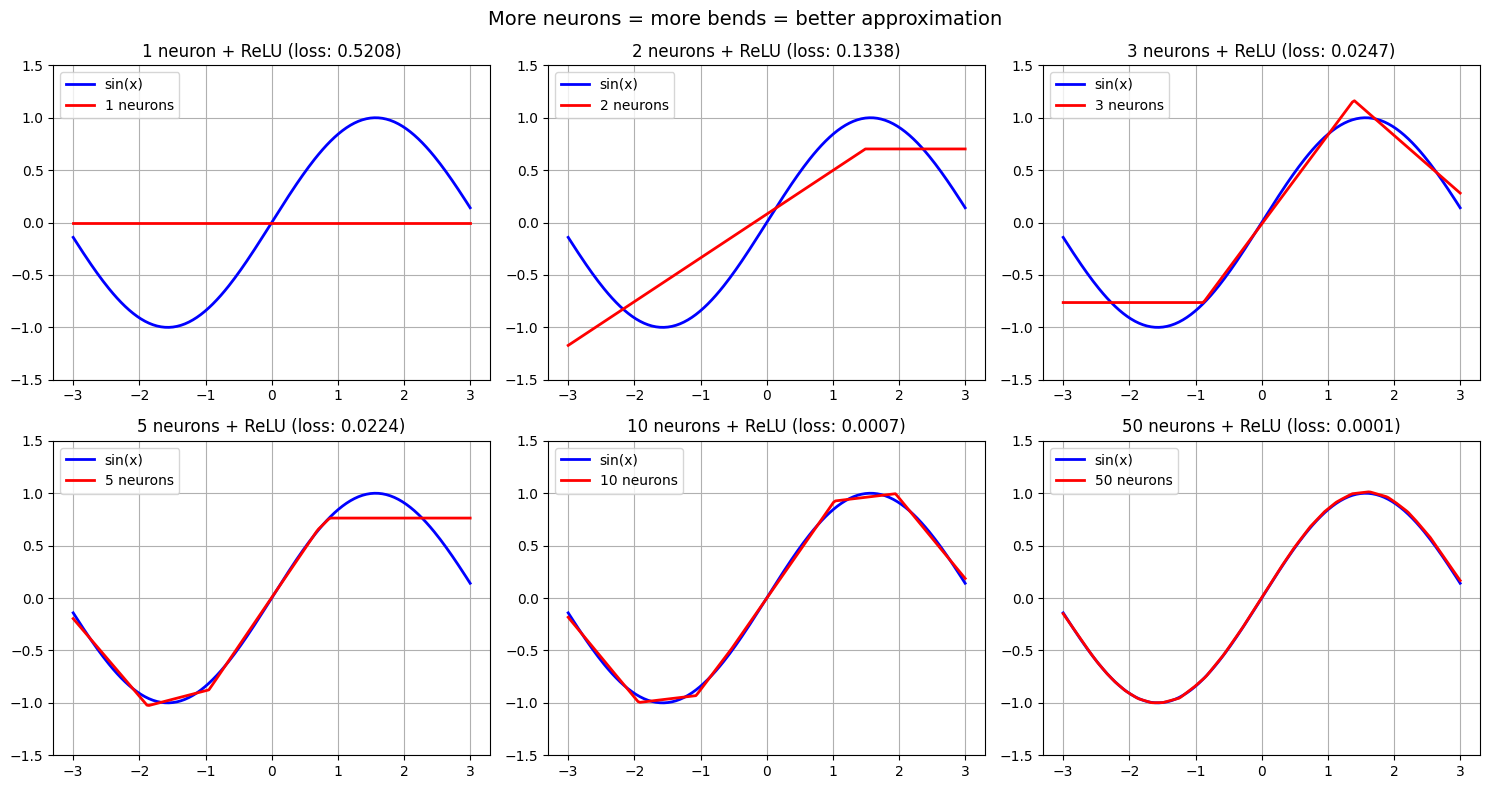

1 neuron: ONE bend. Can only do a kink.
2 neurons: TWO bends. Can go up then down (or vice versa).
3 neurons: THREE bends. Starting to look wavy.
5 neurons: Getting close!
10+ neurons: Nailing it.

Each neuron contributes ONE elbow/kink to the function.
The network literally stitches together straight line segments to fake a curve.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
neuron_counts = [1, 2, 3, 5, 10, 50]

for i, n_neurons in enumerate(neuron_counts):
    ax = axes[i // 3][i % 3]
    
    # Build and train a small network
    net = nn.Sequential(
        nn.Linear(1, n_neurons),
        nn.ReLU(),
        nn.Linear(n_neurons, 1),
    )
    opt = torch.optim.Adam(net.parameters(), lr=0.01)
    
    for step in range(3000):
        pred = net(X)
        loss = loss_fn(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    with torch.no_grad():
        pred = net(X)
    
    ax.plot(X.numpy(), Y.numpy(), 'b-', linewidth=2, label='sin(x)')
    ax.plot(X.numpy(), pred.numpy(), 'r-', linewidth=2, label=f'{n_neurons} neurons')
    ax.set_title(f'{n_neurons} neuron{"s" if n_neurons > 1 else ""} + ReLU (loss: {loss.item():.4f})')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(-1.5, 1.5)

plt.suptitle('More neurons = more bends = better approximation', fontsize=14)
plt.tight_layout()
plt.show()

print("1 neuron: ONE bend. Can only do a kink.")
print("2 neurons: TWO bends. Can go up then down (or vice versa).")
print("3 neurons: THREE bends. Starting to look wavy.")
print("5 neurons: Getting close!")
print("10+ neurons: Nailing it.")
print()
print("Each neuron contributes ONE elbow/kink to the function.")
print("The network literally stitches together straight line segments to fake a curve.")

## The deepest intuition

Without activation: every neuron is a passive pipe. Data flows through, gets mixed,
but the overall function stays a straight line no matter how many neurons or layers.

With activation: every neuron is a **switch** that says:
- "For inputs in THIS region, I'm ON (passing signal through)"
- "For inputs in THAT region, I'm OFF (outputting zero)"

Each neuron **divides the input space into two zones** and behaves differently in each.

More neurons = more zones = the network can have different behavior in more regions
= it can approximate more complex functions.

That's it. That's the whole thing.